In [4]:
!ls

'archive (1).zip'   sample_data


In [5]:
import zipfile
import os

# Exact space matching string variable input
zip_name = 'archive (1).zip'

print(f"📦 Extracting target file: {zip_name}...")

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('titanic_data')

print("✅ Success! Extracted Files:")
print(os.listdir('titanic_data'))

📦 Extracting target file: archive (1).zip...
✅ Success! Extracted Files:
['Titanic-Dataset.csv']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data
file_path = 'titanic_data/Titanic-Dataset.csv'
df = pd.read_csv(file_path)

print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape}")
print(df.head(3))
print("-" * 50)

# 2. Handling Missing Values
# Age missing values ni common ticket class median numbers petti target fill chesthunnam
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked port row errors missing accuracy mode base chesi handle cheddam
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Feature Engineering
# Relative family size determine cheyyadaniki dynamic single feature conversion
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Identification and structure drop matrix mapping text labels
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch'])

# 4. Encoding Categorical Data
# Direct numeric indicators generation string elements format target values ki
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# 5. Dataset Splitting
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Construction & Training
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 7. Complete Performance Check
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n=== MODEL PERFORMANCE METRICS ===")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

=== DATASET OVERVIEW ===
Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
--------------------------------------------------

=== MODEL PERFORMANCE METRICS ===
Validation Accuracy: 81.01%

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82    

/tmp/ipykernel_9859/2370174072.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


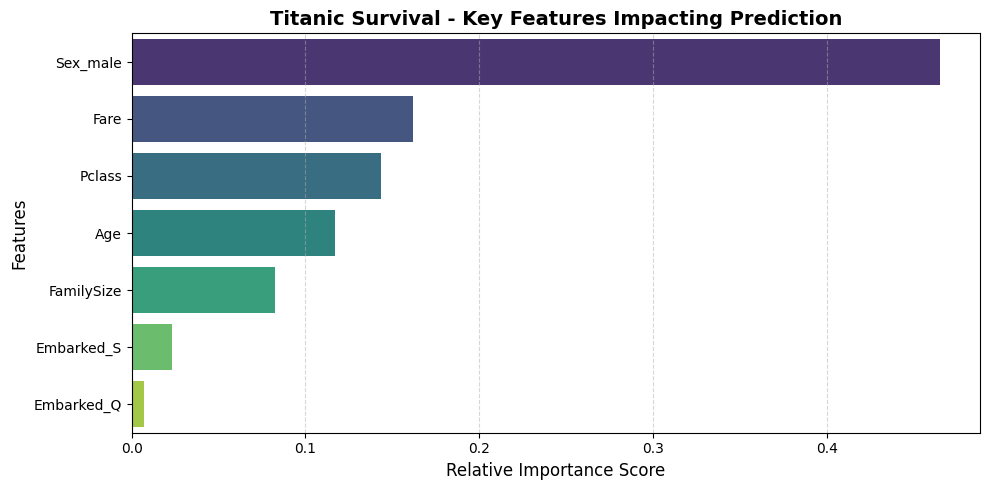

In [7]:
# Calculate feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(10, 5))
plt.title("Titanic Survival - Key Features Impacting Prediction", fontsize=14, fontweight='bold')
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

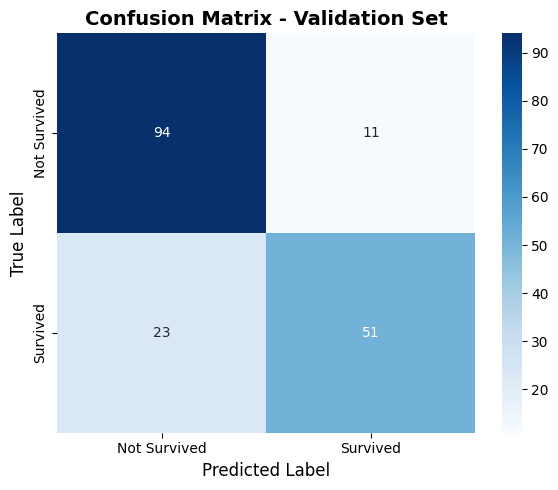

In [8]:
# Generate Confusion Matrix data
cm = confusion_matrix(y_test, y_pred)

# Plotting Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()